# Used Car Price-Value Ratio Arbitrage Study

**Question:** Which used cars in the SGD $60K–$80K bracket offer the best value?

**Data:** Used car listings from SGCarMart, fetched 2026-05-23.
COE-renewed cars (pre-2016) and vans/commercial vehicles excluded via API filters.

In [1]:
import json
import re
from datetime import datetime, date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

TODAY = date(2026, 5, 23)
YEAR_FROM = TODAY.year - 10  # dynamic: excludes cars older than 10 years (COE-renewed)

NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR if (NB_DIR / "data").exists() else NB_DIR.parent
DATA_FILE = PROJECT_ROOT / "data/used_cars/sgd-60k-80k-newest/latest.json"

# Watch config (inline — same as data/used_cars/sgd-60k-80k-newest/config.json)
watch_config = {
    "name": "sgd-60k-80k-newest",
    "filters": {
        "min_price": 60000,
        "max_price": 80000,
        "year_from": YEAR_FROM,
        "vts": 2,                   # "All Passenger Cars" — excludes vans/commercial
        "avl": "a",
        "sortby": "REG_DESC",
        "limit": 100,
    },
    "max_pages": 50,
}
print("Watch config:", json.dumps(watch_config, indent=2))

Watch config: {
  "name": "sgd-60k-80k-newest",
  "filters": {
    "min_price": 60000,
    "max_price": 80000,
    "year_from": 2016,
    "vts": 2,
    "avl": "a",
    "sortby": "REG_DESC",
    "limit": 100
  },
  "max_pages": 50
}


In [2]:
with open(DATA_FILE) as f:
    raw = json.load(f)

listings = list(raw.values())
print(f"Loaded {len(listings)} listings")
print(f"Fields: {list(listings[0].keys())}")

Loaded 1471 listings
Fields: ['id', 'title', 'url', 'price', 'depreciation', 'reg_date', 'coe_left', 'mileage', 'eng_cap', 'owners', 'is_direct_owner', 'is_premium_ad', 'dealer', 'posted_date', 'description']


In [3]:
def parse_coe_left(text):
    if not text: return None
    years = 0.0
    y_match = re.search(r'(\d+)\s*y', text)
    m_match = re.search(r'(\d+)\s*m', text)
    if y_match: years += int(y_match.group(1))
    if m_match: years += int(m_match.group(1)) / 12
    return years if years > 0 else None

def parse_mileage(text):
    if not text: return None
    m = re.search(r'([\d,]+)', text)
    return float(m.group(1).replace(',', '')) if m else None

def parse_eng_cap(text):
    if not text: return None
    m = re.search(r'([\d,]+)', text)
    return float(m.group(1).replace(',', '')) if m else None

def parse_owners(text):
    if not text: return None
    if 'more than' in text.lower():
        m = re.search(r'\d+', text)
        return int(m.group()) + 1 if m else None
    m = re.search(r'(\d+)\s*Owner', text)
    return int(m.group(1)) if m else None

def parse_reg_date(text):
    if not text: return None
    try: return datetime.strptime(text, '%d-%b-%Y').date()
    except ValueError: return None

def extract_brand(title):
    return title.split()[0] if title else ''

print('Parse functions ready.')

Parse functions ready.


In [4]:
rows = []
for car in listings:
    reg_date = parse_reg_date(car.get('reg_date'))
    age = (TODAY - reg_date).days / 365.25 if reg_date else None
    rows.append({
        'id': car['id'], 'title': car['title'],
        'brand': extract_brand(car['title']),
        'price': car.get('price'), 'depreciation': car.get('depreciation'),
        'reg_date': reg_date, 'age_years': age,
        'coe_years_left': parse_coe_left(car.get('coe_left')),
        'mileage_km': parse_mileage(car.get('mileage')),
        'eng_cap_cc': parse_eng_cap(car.get('eng_cap')),
        'num_owners': parse_owners(car.get('owners')),
        'is_direct_owner': car.get('is_direct_owner', False),
        'is_premium_ad': car.get('is_premium_ad', False),
    })

df = pd.DataFrame(rows)
print(f"DataFrame: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nNull counts:")
print(df.isnull().sum())
print(f"\nBasic stats:")
print(df[['price', 'depreciation', 'age_years', 'coe_years_left', 'mileage_km', 'eng_cap_cc', 'num_owners']].describe())

DataFrame: 1471 rows, 13 columns

Null counts:
id                   0
title                0
brand                0
price                0
depreciation        18
reg_date             0
age_years            0
coe_years_left       4
mileage_km         201
eng_cap_cc          13
num_owners           1
is_direct_owner      0
is_premium_ad        0
dtype: int64

Basic stats:
              price  depreciation    age_years  coe_years_left     mileage_km  \
count   1471.000000   1453.000000  1471.000000     1467.000000    1270.000000   
mean   70314.780421  17680.963524     7.538118        3.451261   97829.651969   
std     5737.889452   4245.242050     1.615393        1.278529   38904.054940   
min    60000.000000   6950.000000    -0.610541        0.166667   20900.000000   
25%    65800.000000  14850.000000     6.436687        2.500000   77902.500000   
50%    69888.000000  16680.000000     7.310062        3.416667   95000.000000   
75%    75800.000000  19520.000000     8.655715        4.7500

In [5]:
df['depreciation_rate'] = df['depreciation'] / df['price']
df['est_original_price'] = df['price'] + (df['depreciation'] * df['age_years'])
df['value_retention'] = df['price'] / df['est_original_price']
df['price_per_coe_year'] = df['price'] / df['coe_years_left']
df['depreciation_per_cc'] = df['depreciation'] / df['eng_cap_cc']

df['suspicious'] = (
    (df['value_retention'] > 1.5) | (df['value_retention'] < 0.1) |
    (df['depreciation_rate'] > 1.0) | (df['age_years'] < 0)
)

print(f"Suspicious rows: {df['suspicious'].sum()} / {len(df)}")
clean = df[~df['suspicious'] & df['price'].notna() & df['depreciation'].notna()].copy()
print(f"Clean dataset: {len(clean)} listings")
print("\nValue characteristics summary:")
print(clean[['depreciation_rate', 'value_retention', 'price_per_coe_year', 'depreciation_per_cc']].describe())

Suspicious rows: 1 / 1471
Clean dataset: 1452 listings

Value characteristics summary:
       depreciation_rate  value_retention  price_per_coe_year  \
count        1452.000000      1452.000000         1452.000000   
mean            0.252774         0.358946        24122.432554   
std             0.062455         0.079056        12806.149603   
min             0.100000         0.126847         7065.420561   
25%             0.202405         0.318632        15597.490246   
50%             0.239843         0.340298        20543.589744   
75%             0.281752         0.397845        27920.000000   
max             0.735795         0.997542       136971.428571   

       depreciation_per_cc  
count          1439.000000  
mean                   inf  
std                    NaN  
min               2.347973  
25%               9.254491  
50%              10.283648  
75%              11.693640  
max                    inf  


/Users/shuisongluar/projects/sgcarmart-data/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


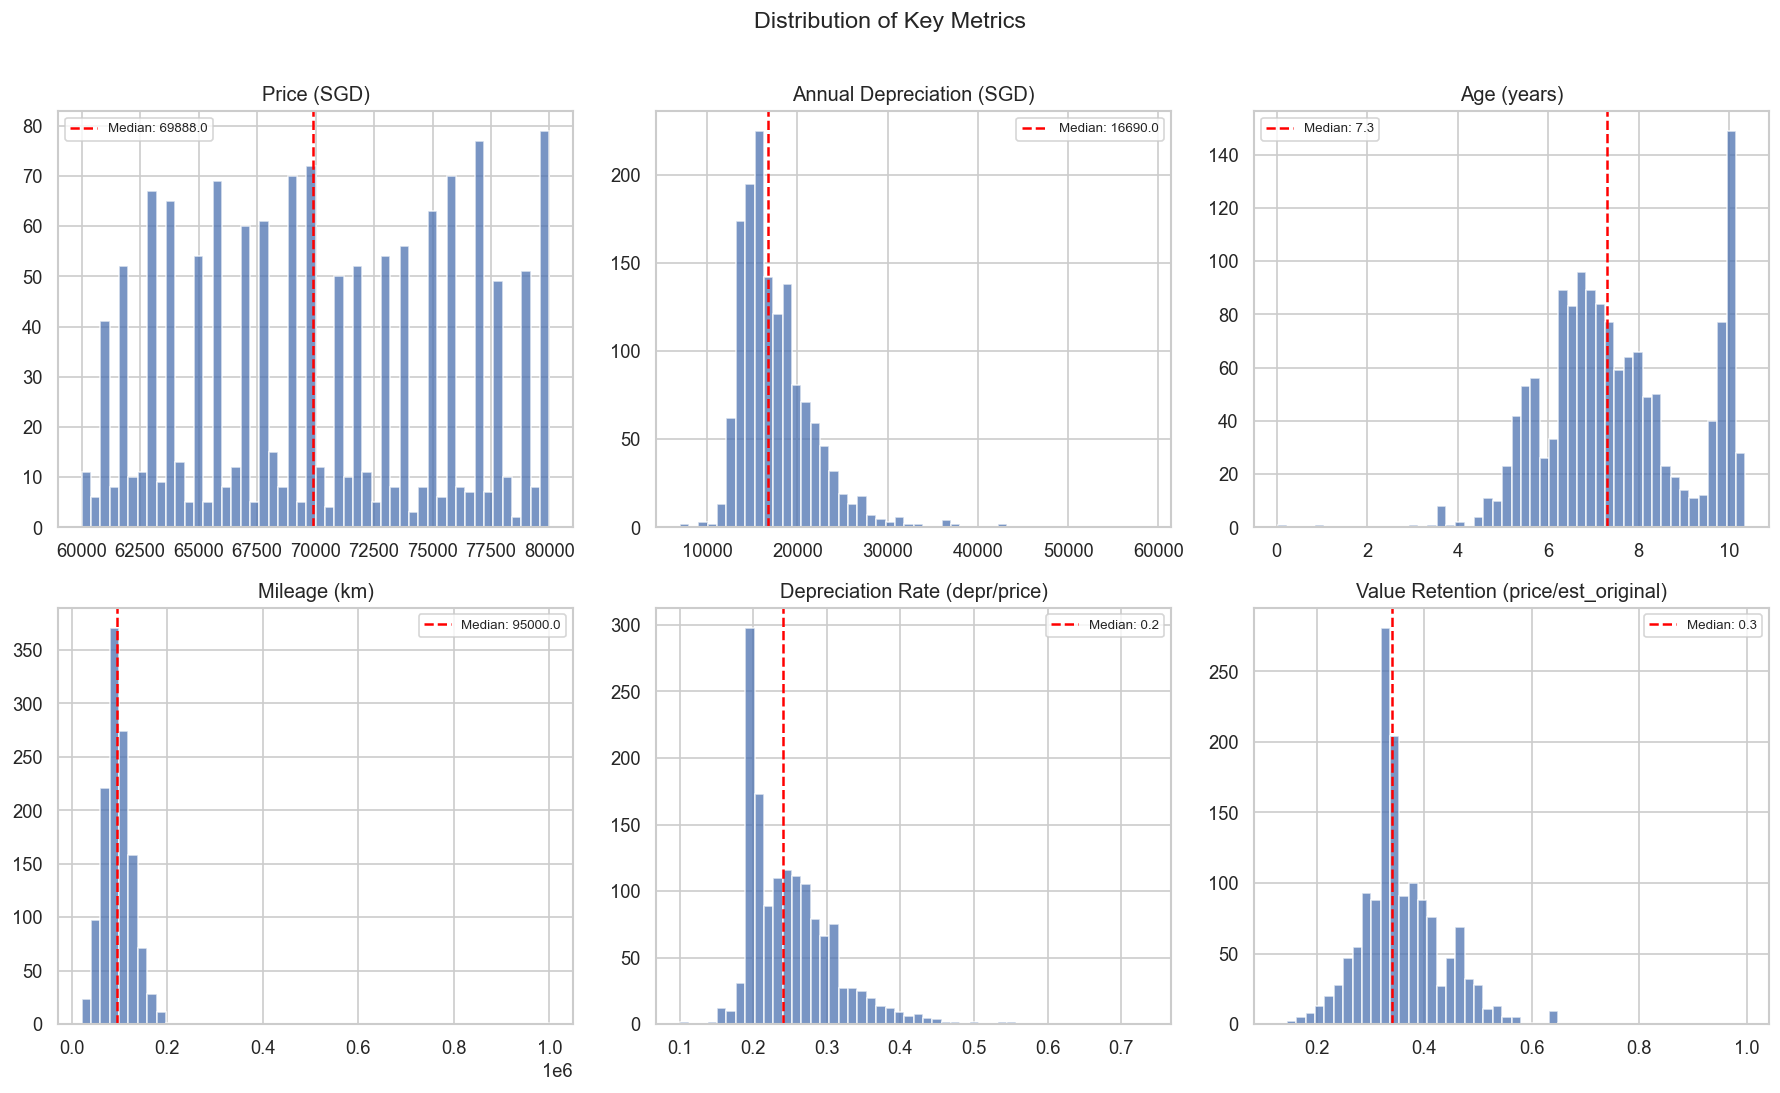

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
metrics = [
    ('price', 'Price (SGD)', 'Greens'),
    ('depreciation', 'Annual Depreciation (SGD)', 'Reds'),
    ('age_years', 'Age (years)', 'Blues'),
    ('mileage_km', 'Mileage (km)', 'Oranges'),
    ('depreciation_rate', 'Depreciation Rate (depr/price)', 'Purples'),
    ('value_retention', 'Value Retention (price/est_original)', 'Greys'),
]
for ax, (col, label, _) in zip(axes, metrics):
    data = clean[col].dropna()
    ax.hist(data, bins=50, alpha=0.75, edgecolor='white')
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.1f}')
    ax.set_title(label); ax.legend(fontsize=8)
fig.suptitle('Distribution of Key Metrics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

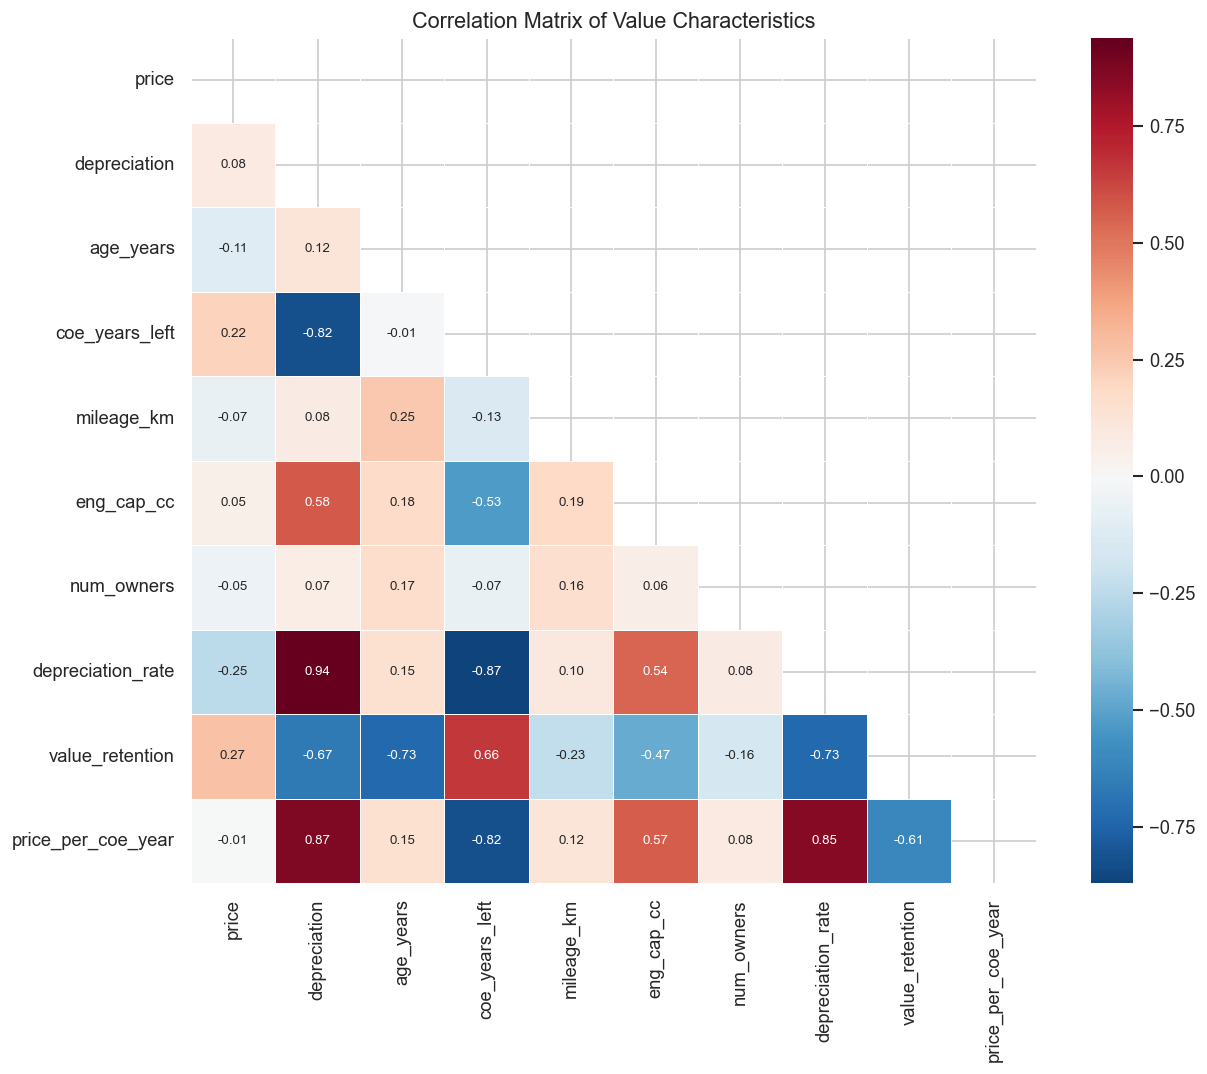

In [7]:
corr_cols = ['price', 'depreciation', 'age_years', 'coe_years_left', 'mileage_km',
             'eng_cap_cc', 'num_owners', 'depreciation_rate', 'value_retention',
             'price_per_coe_year']
corr = clean[corr_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'fontsize': 8})
ax.set_title('Correlation Matrix of Value Characteristics', fontsize=13)
plt.tight_layout(); plt.show()

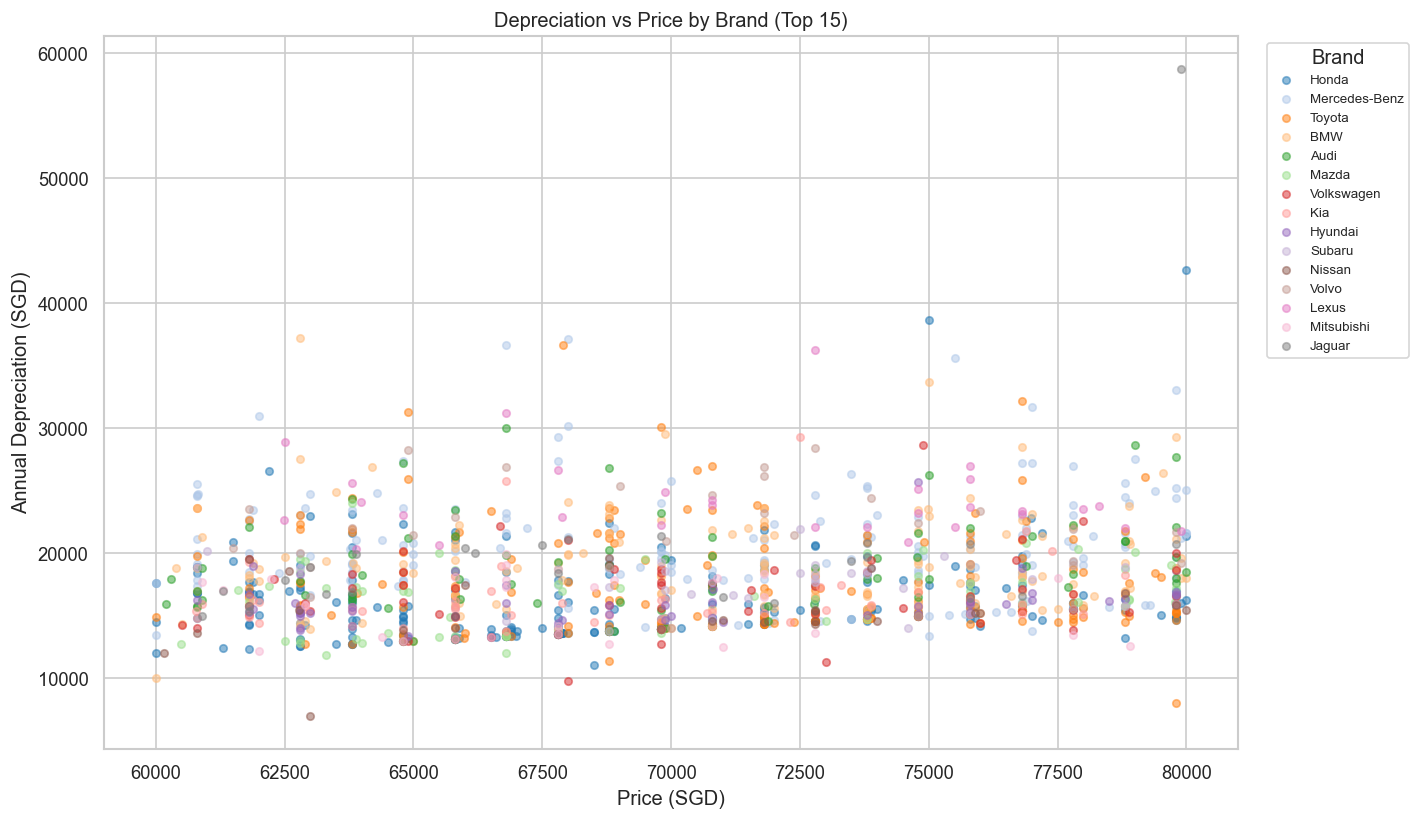

In [8]:
top_brands = clean['brand'].value_counts().head(15).index
plot_df = clean[clean['brand'].isin(top_brands)]
fig, ax = plt.subplots(figsize=(12, 7))
colors = sns.color_palette('tab20', len(top_brands))
for i, brand in enumerate(top_brands):
    brand_data = plot_df[plot_df['brand'] == brand]
    ax.scatter(brand_data['price'], brand_data['depreciation'],
               c=[colors[i]], label=brand, alpha=0.5, s=20)
ax.set_xlabel('Price (SGD)'); ax.set_ylabel('Annual Depreciation (SGD)')
ax.set_title('Depreciation vs Price by Brand (Top 15)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Brand')
plt.tight_layout(); plt.show()

In [9]:
print('## Top 10 — Lowest Depreciation Rate')
print()
for i, (_, row) in enumerate(clean.nsmallest(10, 'depreciation_rate').iterrows()):
    print(f"{i+1}. **{row['title']}**")
    print(f"   Price: ${row['price']:,.0f} | Depr: ${row['depreciation']:,.0f}/yr ({row['depreciation_rate']*100:.1f}% of price)")
    print(f"   Age: {row['age_years']:.1f}y | COE left: {row['coe_years_left']:.1f}y | Mileage: {row['mileage_km']:,.0f} km | Brand: {row['brand']}")
    print()

## Top 10 — Lowest Depreciation Rate

1. **Toyota Starlet Turbo S 5DR (COE till 05/2036)**
   Price: $79,800 | Depr: $7,980/yr (10.0% of price)
   Age: 0.0y | COE left: 9.9y | Mileage: 56,985 km | Brand: Toyota

2. **Nissan Fairlady 300ZX (COE till 05/2035)**
   Price: $63,000 | Depr: $6,950/yr (11.0% of price)
   Age: 1.0y | COE left: 8.9y | Mileage: 103,888 km | Brand: Nissan

3. **Austin Healey Sprite (COE till 05/2033)**
   Price: $69,000 | Depr: $9,830/yr (14.2% of price)
   Age: 3.0y | COE left: 7.0y | Mileage: 84,500 km | Brand: Austin

4. **Volkswagen Karmann Ghia 1.6M (COE till 05/2032)**
   Price: $68,000 | Depr: $9,800/yr (14.4% of price)
   Age: 4.0y | COE left: 6.0y | Mileage: nan km | Brand: Volkswagen

5. **Opel Corsa-e Electric**
   Price: $80,000 | Depr: $12,080/yr (15.1% of price)
   Age: 3.4y | COE left: 6.6y | Mileage: nan km | Brand: Opel

6. **Volkswagen Kombi (COE till 10/2032)**
   Price: $73,000 | Depr: $11,320/yr (15.5% of price)
   Age: 3.6y | COE left: 6.4y 

In [10]:
print('## Top 10 — Highest Value Retention')
print()
for i, (_, row) in enumerate(clean.nlargest(10, 'value_retention').iterrows()):
    print(f"{i+1}. **{row['title']}**")
    print(f"   Price: ${row['price']:,.0f} | Est Original: ${row['est_original_price']:,.0f} | Retention: {row['value_retention']:.1%}")
    print(f"   Age: {row['age_years']:.1f}y | COE left: {row['coe_years_left']:.1f}y | Mileage: {row['mileage_km']:,.0f} km | Brand: {row['brand']}")
    print()

## Top 10 — Highest Value Retention

1. **Toyota Starlet Turbo S 5DR (COE till 05/2036)**
   Price: $79,800 | Est Original: $79,997 | Retention: 99.8%
   Age: 0.0y | COE left: 9.9y | Mileage: 56,985 km | Brand: Toyota

2. **Nissan Fairlady 300ZX (COE till 05/2035)**
   Price: $63,000 | Est Original: $70,021 | Retention: 90.0%
   Age: 1.0y | COE left: 8.9y | Mileage: 103,888 km | Brand: Nissan

3. **Austin Healey Sprite (COE till 05/2033)**
   Price: $69,000 | Est Original: $98,308 | Retention: 70.2%
   Age: 3.0y | COE left: 7.0y | Mileage: 84,500 km | Brand: Austin

4. **Opel Corsa-e Electric**
   Price: $80,000 | Est Original: $120,845 | Retention: 66.2%
   Age: 3.4y | COE left: 6.6y | Mileage: nan km | Brand: Opel

5. **Volkswagen Kombi (COE till 10/2032)**
   Price: $73,000 | Est Original: $113,414 | Retention: 64.4%
   Age: 3.6y | COE left: 6.4y | Mileage: 32,035 km | Brand: Volkswagen

6. **Opel Corsa-e Electric**
   Price: $77,000 | Est Original: $119,768 | Retention: 64.3%
   Ag

In [11]:
print('## Top 10 — Lowest Price per COE Year')
print()
for i, (_, row) in enumerate(clean.nsmallest(10, 'price_per_coe_year').iterrows()):
    print(f"{i+1}. **{row['title']}**")
    print(f"   Price: ${row['price']:,.0f} | COE left: {row['coe_years_left']:.1f}y | ${row['price_per_coe_year']:,.0f}/COE-year")
    print(f"   Depr: ${row['depreciation']:,.0f}/yr | Age: {row['age_years']:.1f}y | Mileage: {row['mileage_km']:,.0f} km | Brand: {row['brand']}")
    print()

## Top 10 — Lowest Price per COE Year

1. **Nissan Fairlady 300ZX (COE till 05/2035)**
   Price: $63,000 | COE left: 8.9y | $7,065/COE-year
   Depr: $6,950/yr | Age: 1.0y | Mileage: 103,888 km | Brand: Nissan

2. **Toyota Starlet Turbo S 5DR (COE till 05/2036)**
   Price: $79,800 | COE left: 9.9y | $8,047/COE-year
   Depr: $7,980/yr | Age: 0.0y | Mileage: 56,985 km | Brand: Toyota

3. **Austin Healey Sprite (COE till 05/2033)**
   Price: $69,000 | COE left: 7.0y | $9,857/COE-year
   Depr: $9,830/yr | Age: 3.0y | Mileage: 84,500 km | Brand: Austin

4. **BMW 2002 (COE till 05/2032)**
   Price: $60,000 | COE left: 5.9y | $10,141/COE-year
   Depr: $10,020/yr | Age: 4.0y | Mileage: nan km | Brand: BMW

5. **Volkswagen Karmann Ghia 1.6M (COE till 05/2032)**
   Price: $68,000 | COE left: 6.0y | $11,333/COE-year
   Depr: $9,800/yr | Age: 4.0y | Mileage: nan km | Brand: Volkswagen

6. **Volkswagen Kombi (COE till 10/2032)**
   Price: $73,000 | COE left: 6.4y | $11,377/COE-year
   Depr: $11,320/

In [12]:
brand_stats = clean.groupby('brand').agg(
    count=('id', 'count'), median_price=('price', 'median'),
    median_depreciation_rate=('depreciation_rate', 'median'),
    median_value_retention=('value_retention', 'median'),
    median_price_per_coe_year=('price_per_coe_year', 'median'),
    median_age=('age_years', 'median'), median_mileage=('mileage_km', 'median'),
).query('count >= 10').sort_values('median_depreciation_rate')

print('## Brand Value Rankings (min 10 listings)')
print(f"\n{'Brand':<20} {'#':>4} {'Med Price':>10} {'Med DeprRate':>11} {'Med Retention':>12} {'Med $/COEyr':>11}")
print('-' * 72)
for brand, row in brand_stats.iterrows():
    print(f"{brand:<20} {int(row['count']):>4} ${row['median_price']:>8,.0f} "
          f"{row['median_depreciation_rate']:>10.1%} {row['median_value_retention']:>11.1%} "
          f"${row['median_price_per_coe_year']:>9,.0f}")
print()
print('## Top 10 Brands by Lowest Depreciation Rate')
for i, (brand, row) in enumerate(brand_stats.head(10).iterrows()):
    print(f"{i+1}. **{brand}** — {row['median_depreciation_rate']:.1%} depr rate, "
          f"{row['median_value_retention']:.1%} retention, "
          f"${row['median_price']:,.0f} median price ({int(row['count'])} listings)")

## Brand Value Rankings (min 10 listings)

Brand                   #  Med Price Med DeprRate Med Retention Med $/COEyr
------------------------------------------------------------------------
Opel                   22 $  75,800      18.2%       53.5% $   14,343
Nissan                 33 $  68,800      20.2%       41.5% $   16,569
Suzuki                 18 $  72,844      20.5%       45.3% $   17,263
Honda                 251 $  67,900      20.8%       34.2% $   15,665
Mazda                  67 $  67,800      21.1%       35.1% $   18,432
Toyota                197 $  71,800      21.4%       33.6% $   17,511
Hyundai                50 $  68,344      22.3%       41.7% $   17,502
Mitsubishi             27 $  66,800      23.2%       36.3% $   20,514
Kia                    52 $  67,800      23.6%       39.5% $   17,536
Volkswagen             60 $  69,800      23.8%       37.2% $   21,048
Subaru                 33 $  72,500      24.7%       38.0% $   20,595
Skoda                  24 $  68,800   

In [13]:
scoring = clean[['depreciation_rate', 'value_retention', 'price_per_coe_year']].dropna().copy()
d_min, d_max = scoring['depreciation_rate'].min(), scoring['depreciation_rate'].max()
r_min, r_max = scoring['value_retention'].min(), scoring['value_retention'].max()
p_min, p_max = scoring['price_per_coe_year'].min(), scoring['price_per_coe_year'].max()

scoring['depr_score'] = 1 - (scoring['depreciation_rate'] - d_min) / (d_max - d_min)
scoring['retention_score'] = (scoring['value_retention'] - r_min) / (r_max - r_min)
scoring['ppy_score'] = 1 - (scoring['price_per_coe_year'] - p_min) / (p_max - p_min)
scoring['composite_score'] = scoring['depr_score'] * 0.40 + scoring['retention_score'] * 0.35 + scoring['ppy_score'] * 0.25

clean_scored = clean.loc[scoring.index].copy()
clean_scored['composite_score'] = scoring['composite_score']
top_value = clean_scored.nlargest(15, 'composite_score')

print('## Top 15 — Composite Value Score')
print('\nScore = 0.40 x (1-norm_depr) + 0.35 x norm_retention + 0.25 x (1-norm_ppy)\n')
for i, (_, row) in enumerate(top_value.iterrows()):
    print(f"{i+1}. **{row['title']}** ({row['brand']}) — Score: {row['composite_score']:.3f}")
    print(f"   ${row['price']:,.0f} | Depr: ${row['depreciation']:,.0f}/yr ({row['depreciation_rate']:.1%}) | "
          f"Retention: {row['value_retention']:.1%} | ${row['price_per_coe_year']:,.0f}/COE-yr")
    print(f"   Age: {row['age_years']:.1f}y | COE left: {row['coe_years_left']:.1f}y | "
          f"Mileage: {row['mileage_km']:,.0f} km")
    print()

## Top 15 — Composite Value Score

Score = 0.40 x (1-norm_depr) + 0.35 x norm_retention + 0.25 x (1-norm_ppy)

1. **Toyota Starlet Turbo S 5DR (COE till 05/2036)** (Toyota) — Score: 0.998
   $79,800 | Depr: $7,980/yr (10.0%) | Retention: 99.8% | $8,047/COE-yr
   Age: 0.0y | COE left: 9.9y | Mileage: 56,985 km

2. **Nissan Fairlady 300ZX (COE till 05/2035)** (Nissan) — Score: 0.954
   $63,000 | Depr: $6,950/yr (11.0%) | Retention: 90.0% | $7,065/COE-yr
   Age: 1.0y | COE left: 8.9y | Mileage: 103,888 km

3. **Austin Healey Sprite (COE till 05/2033)** (Austin) — Score: 0.849
   $69,000 | Depr: $9,830/yr (14.2%) | Retention: 70.2% | $9,857/COE-yr
   Age: 3.0y | COE left: 7.0y | Mileage: 84,500 km

4. **Opel Corsa-e Electric** (Opel) — Score: 0.823
   $80,000 | Depr: $12,080/yr (15.1%) | Retention: 66.2% | $12,152/COE-yr
   Age: 3.4y | COE left: 6.6y | Mileage: nan km

5. **Volkswagen Karmann Ghia 1.6M (COE till 05/2032)** (Volkswagen) — Score: 0.819
   $68,000 | Depr: $9,800/yr (14.4%) | 

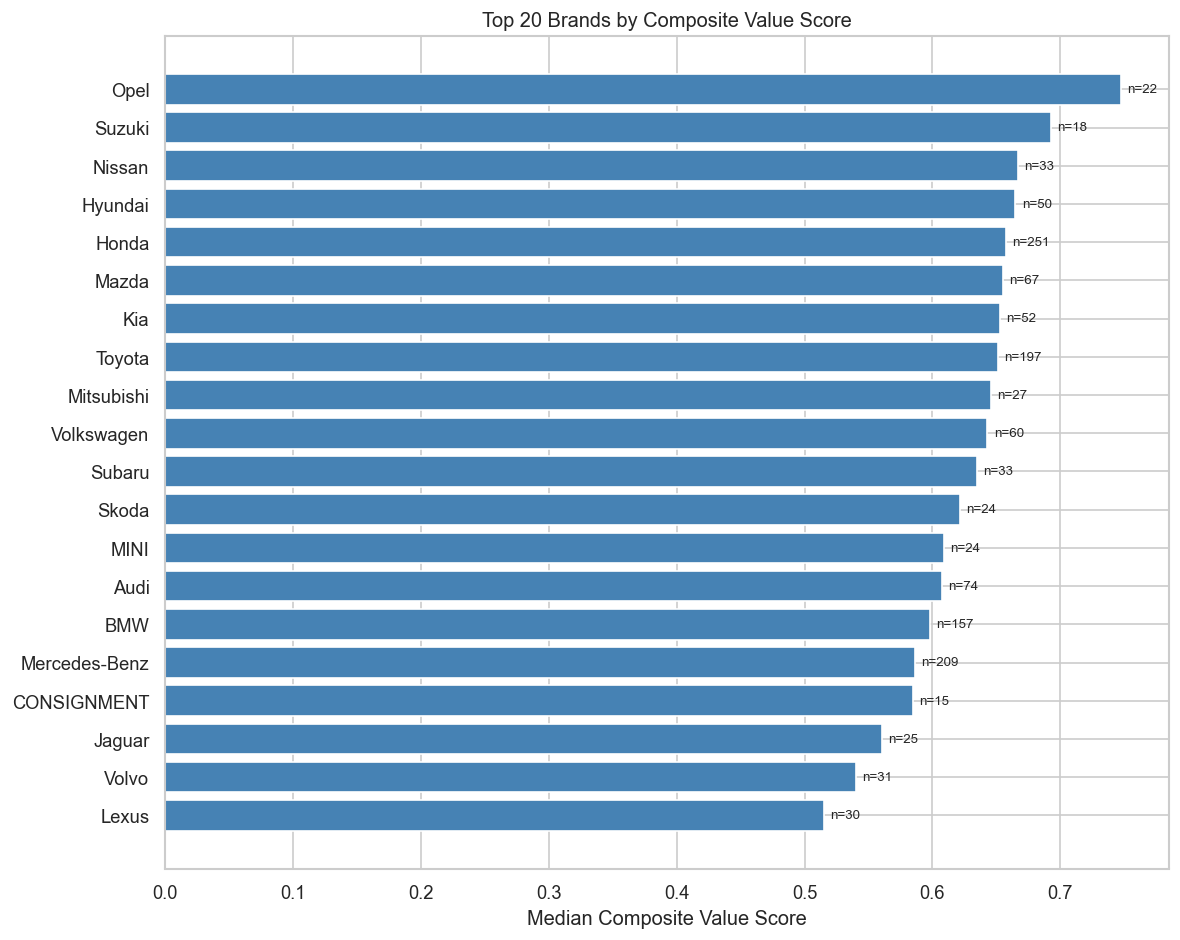

## Top 10 Brands by Composite Value Score

1. **Opel** — Score: 0.747 | $75,800 median | 18.2% depr | 53.5% retention (22 listings)
2. **Suzuki** — Score: 0.693 | $72,844 median | 20.5% depr | 45.3% retention (18 listings)
3. **Nissan** — Score: 0.667 | $68,800 median | 20.2% depr | 41.5% retention (33 listings)
4. **Hyundai** — Score: 0.665 | $68,344 median | 22.3% depr | 41.7% retention (50 listings)
5. **Honda** — Score: 0.657 | $67,900 median | 20.8% depr | 34.2% retention (251 listings)
6. **Mazda** — Score: 0.655 | $67,800 median | 21.1% depr | 35.1% retention (67 listings)
7. **Kia** — Score: 0.653 | $67,800 median | 23.6% depr | 39.5% retention (52 listings)
8. **Toyota** — Score: 0.651 | $71,800 median | 21.4% depr | 33.6% retention (197 listings)
9. **Mitsubishi** — Score: 0.646 | $66,800 median | 23.2% depr | 36.3% retention (27 listings)
10. **Volkswagen** — Score: 0.643 | $69,800 median | 23.8% depr | 37.2% retention (60 listings)


In [14]:
brand_composite = clean_scored.groupby('brand').agg(
    count=('id', 'count'), median_score=('composite_score', 'median'),
    median_price=('price', 'median'), median_depr_rate=('depreciation_rate', 'median'),
    median_retention=('value_retention', 'median'), median_ppy=('price_per_coe_year', 'median'),
).query('count >= 10').sort_values('median_score', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(brand_composite))
plot_brands = brand_composite.head(top_n)
ax.barh(range(len(plot_brands)), plot_brands['median_score'], color='steelblue')
ax.set_yticks(range(len(plot_brands)))
ax.set_yticklabels(plot_brands.index); ax.invert_yaxis()
ax.set_xlabel('Median Composite Value Score')
ax.set_title(f'Top {top_n} Brands by Composite Value Score')
for i, (_, row) in enumerate(plot_brands.iterrows()):
    ax.text(row['median_score'] + 0.005, i, f"n={int(row['count'])}", va='center', fontsize=8)
plt.tight_layout(); plt.show()

print('## Top 10 Brands by Composite Value Score\n')
for i, (brand, row) in enumerate(brand_composite.head(10).iterrows()):
    print(f"{i+1}. **{brand}** — Score: {row['median_score']:.3f} | "
          f"${row['median_price']:,.0f} median | "
          f"{row['median_depr_rate']:.1%} depr | "
          f"{row['median_retention']:.1%} retention ({int(row['count'])} listings)")

## Summary & Caveats

### Data Filters Applied
- Price bracket: SGD $60K–$80K
- Registration year >= 2016 (excludes COE-renewed cars)
- Vehicle type: All Passenger Cars (`vts=2`) — excludes vans, trucks, commercial vehicles

### Key Findings
The analysis identifies cars and brands offering the best value across three dimensions:
1. **Lowest depreciation rate** — cheapest to own annually relative to purchase price
2. **Highest value retention** — cars that have held their original value best
3. **Lowest price per COE year** — best price per year of remaining usable life
4. **Composite score** — balanced ranking combining all three

### Data Limitations
- **Depreciation is seller-stated**, not independently computed
- **Estimated original price** is a rough linear extrapolation (`price + depreciation * age`)
- **OMV, ARF, dereg_value** are available via the detail-page scraper (`UsedCarDetail`) but require per-car page loads
- **COE category** (Cat A/B) is not captured — affects depreciation patterns significantly
- The data represents a **single snapshot** (2026-05-23); trends over time may differ

### Next Steps
- Re-run with `UsedCarDetail` scraping for a smaller sample to incorporate OMV/ARF/dereg_value
- Expand to other price brackets
- Track value scores over time as more daily snapshots accumulate